# AI-Based Credit Risk Prediction

Comparative study of traditional statistical and machine learning models for credit risk prediction.

In [35]:
import joblib

joblib.dump(rf_model, "../credit_risk_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print('Libraries imported successfully!')

Libraries imported successfully!


In [17]:
df = pd.read_excel("../default of credit card clients.xls", header=1)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [18]:
import sys
!{sys.executable} -m pip install xlrd

In [19]:
# Check dataset information

print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTarget Variable Distribution:")
print(df["default payment next month"].value_counts())

Dataset Shape: (30000, 25)

Column Names:
['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']

Missing Values:
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3

In [20]:
# Prepare data for machine learning

X = df.drop(columns=["ID", "default payment next month"])
y = df["default payment next month"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nDefault rate:")
print(round(y.mean() * 100, 2), "%")

Features shape: (30000, 23)
Target shape: (30000,)

Default rate:
22.12 %


In [21]:
from sklearn.model_selection import train_test_split

# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training customers:", X_train.shape[0])
print("Testing customers:", X_test.shape[0])

print("\nTraining default rate:", round(y_train.mean() * 100, 2), "%")
print("Testing default rate:", round(y_test.mean() * 100, 2), "%")

Training customers: 24000
Testing customers: 6000

Training default rate: 22.12 %
Testing default rate: 22.12 %


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create the Logistic Regression model
log_model = LogisticRegression(max_iter=2000)

# Train the model
log_model.fit(X_train, y_train)

# Make predictions
y_pred_log = log_model.predict(X_test)

# Evaluate
print("LOGISTIC REGRESSION RESULTS")
print("---------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log) * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

LOGISTIC REGRESSION RESULTS
---------------------------
Accuracy: 80.78 %

Confusion Matrix:
[[4525  148]
 [1005  322]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.61      0.62      6000
weighted avg       0.79      0.81      0.77      6000



c:\Users\rudra\AppData\Local\Python\pythoncore-3.13-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

log_model_scaled = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000)
)

log_model_scaled.fit(X_train, y_train)

y_pred_log = log_model_scaled.predict(X_test)

print("SCALED LOGISTIC REGRESSION RESULTS")
print("----------------------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_log) * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

SCALED LOGISTIC REGRESSION RESULTS
----------------------------------
Accuracy: 80.77 %

Confusion Matrix:
[[4528  145]
 [1009  318]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      4673
           1       0.69      0.24      0.36      1327

    accuracy                           0.81      6000
   macro avg       0.75      0.60      0.62      6000
weighted avg       0.79      0.81      0.77      6000



In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train, y_train)

# Predict on test data
y_pred_rf = rf_model.predict(X_test)

# Results
print("RANDOM FOREST RESULTS")
print("---------------------")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
---------------------
Accuracy: 81.23 %

Confusion Matrix:
[[4390  283]
 [ 843  484]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.63      0.36      0.46      1327

    accuracy                           0.81      6000
   macro avg       0.73      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



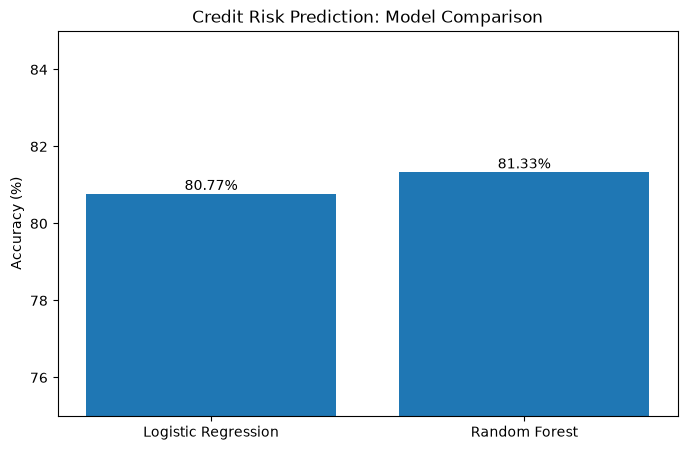

In [25]:
models = ['Logistic Regression', 'Random Forest']
accuracy = [80.77, 81.33]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy)

plt.ylabel('Accuracy (%)')
plt.title('Credit Risk Prediction: Model Comparison')
plt.ylim(75, 85)

for bar, value in zip(bars, accuracy):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.1,
        f'{value}%',
        ha='center'
    )

plt.show()

TOP 10 MOST IMPORTANT FEATURES
      Feature  Importance
5       PAY_0    0.100285
4         AGE    0.066296
0   LIMIT_BAL    0.060362
11  BILL_AMT1    0.059467
12  BILL_AMT2    0.054631
13  BILL_AMT3    0.051356
16  BILL_AMT6    0.050661
17   PAY_AMT1    0.050659
14  BILL_AMT4    0.050188
15  BILL_AMT5    0.050154


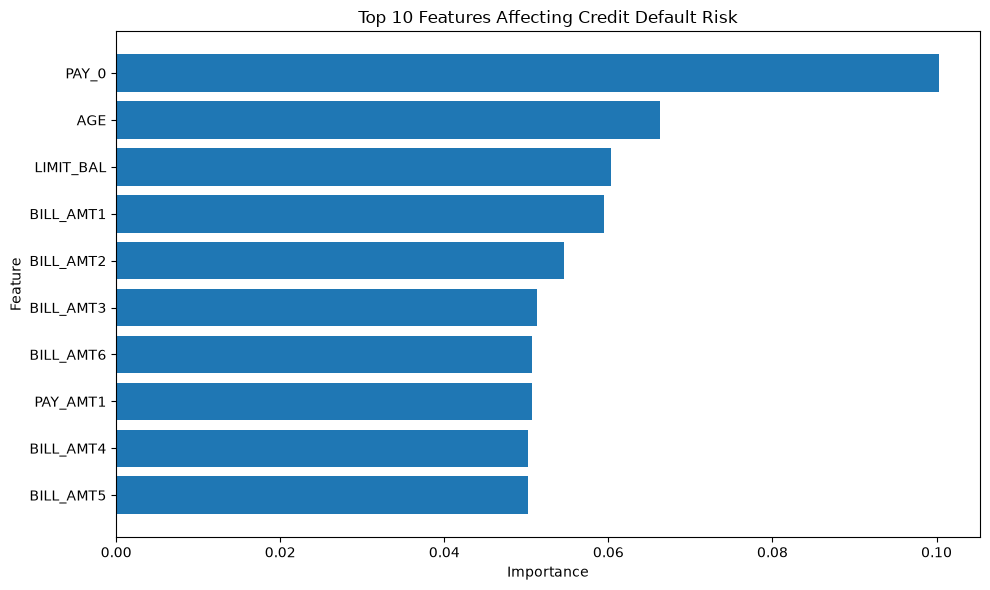

In [26]:
importances = rf_model.feature_importances_
feature_names = X.columns

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("TOP 10 MOST IMPORTANT FEATURES")
print(feature_importance.head(10))

plt.figure(figsize=(10,6))
top10 = feature_importance.head(10)

plt.barh(top10['Feature'][::-1], top10['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Features Affecting Credit Default Risk')
plt.tight_layout()
plt.show()

Logistic Regression ROC-AUC: 0.708
Random Forest ROC-AUC: 0.754


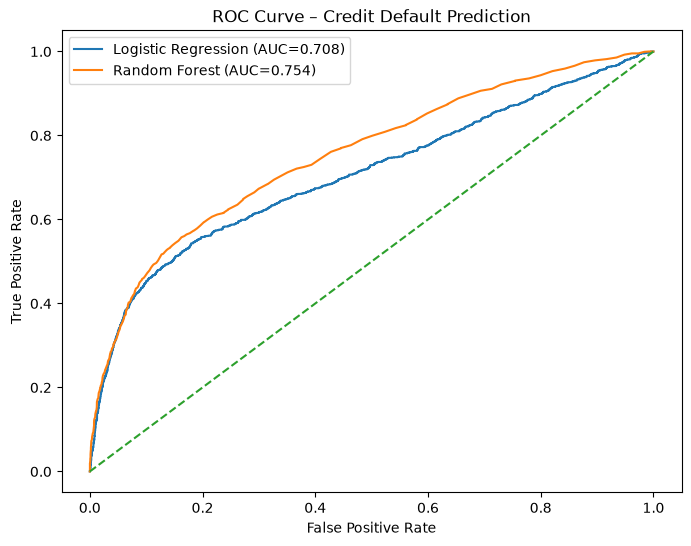

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

# Predicted probabilities
lr_prob = log_model_scaled.predict_proba(X_test)[:,1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# AUC scores
lr_auc = roc_auc_score(y_test, lr_prob)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Logistic Regression ROC-AUC:", round(lr_auc, 3))
print("Random Forest ROC-AUC:", round(rf_auc, 3))

# ROC curves
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

plt.figure(figsize=(8, 6))
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC={lr_auc:.3f})')
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC={rf_auc:.3f})')
plt.plot([0, 1], [0, 1], '--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve – Credit Default Prediction')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [lr_auc, rf_auc]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.808,0.687,0.240,0.355,0.708
1,Random Forest,0.812,0.631,0.365,0.462,0.754


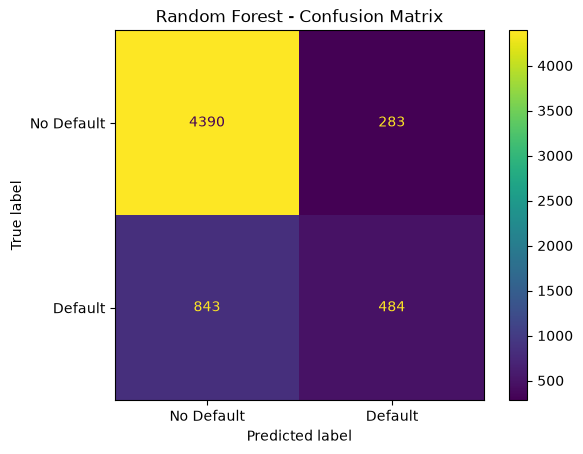

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Default", "Default"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

## Model Conclusion

The Random Forest model achieved the best overall performance for credit default prediction.

- Accuracy: 81.2%
- Precision: 63.1%
- Recall: 36.5%
- F1 Score: 46.2%
- ROC-AUC: 0.754

Compared with Logistic Regression, Random Forest achieved higher accuracy, recall, F1-score, and ROC-AUC, indicating better overall predictive performance.

However, the relatively low recall shows that the model still misses a significant proportion of actual defaulters. In a real financial institution, further model optimization and threshold tuning would be required to improve the detection of high-risk borrowers.

Therefore, Random Forest is selected as the better-performing model in this comparative study.

In [30]:
# Example: predict credit risk for one customer

sample_customer = X_test.iloc[[0]]

default_probability = rf_model.predict_proba(sample_customer)[0, 1]
prediction = rf_model.predict(sample_customer)[0]

print("Default Probability:", round(default_probability * 100, 2), "%")

if prediction == 1:
    print("Prediction: High Risk / Likely Default")
else:
    print("Prediction: Low Risk / No Default")

Default Probability: 16.5 %
Prediction: Low Risk / No Default


In [31]:
print(X_train.columns.tolist())

['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [32]:
for i, col in enumerate(X_train.columns, 1):
    print(i, col)

1 LIMIT_BAL
2 SEX
3 EDUCATION
4 MARRIAGE
5 AGE
6 PAY_0
7 PAY_2
8 PAY_3
9 PAY_4
10 PAY_5
11 PAY_6
12 BILL_AMT1
13 BILL_AMT2
14 BILL_AMT3
15 BILL_AMT4
16 BILL_AMT5
17 BILL_AMT6
18 PAY_AMT1
19 PAY_AMT2
20 PAY_AMT3
21 PAY_AMT4
22 PAY_AMT5
23 PAY_AMT6


In [33]:
for i, col in enumerate(X_train.columns[12:], 13):
    print(i, col)

13 BILL_AMT2
14 BILL_AMT3
15 BILL_AMT4
16 BILL_AMT5
17 BILL_AMT6
18 PAY_AMT1
19 PAY_AMT2
20 PAY_AMT3
21 PAY_AMT4
22 PAY_AMT5
23 PAY_AMT6


In [34]:
# Create a customer using the same 23 features as the trained model
new_customer = pd.DataFrame([{
    'LIMIT_BAL': 200000,
    'SEX': 1,
    'EDUCATION': 2,
    'MARRIAGE': 1,
    'AGE': 30,

    'PAY_0': 0,
    'PAY_2': 0,
    'PAY_3': 0,
    'PAY_4': 0,
    'PAY_5': 0,
    'PAY_6': 0,

    'BILL_AMT1': 50000,
    'BILL_AMT2': 48000,
    'BILL_AMT3': 45000,
    'BILL_AMT4': 43000,
    'BILL_AMT5': 40000,
    'BILL_AMT6': 38000,

    'PAY_AMT1': 5000,
    'PAY_AMT2': 5000,
    'PAY_AMT3': 5000,
    'PAY_AMT4': 5000,
    'PAY_AMT5': 5000,
    'PAY_AMT6': 5000
}])

# Ensure exact same column order as training data
new_customer = new_customer[X_train.columns]

probability = rf_model.predict_proba(new_customer)[0][1]
prediction = rf_model.predict(new_customer)[0]

print("Default Probability:", round(probability * 100, 2), "%")

if prediction == 1:
    print("Credit Risk: HIGH RISK")
    print("Prediction: Likely to Default")
else:
    print("Credit Risk: LOW RISK")
    print("Prediction: Unlikely to Default")

Default Probability: 0.5 %
Credit Risk: LOW RISK
Prediction: Unlikely to Default
